# 量化买入分析示例：用数据回答"什么时候买、买多少"

本 notebook 展示一个完整的量化买入分析流程，数据全部来自本仓库：

- 指数行情：`02_Market/data/indices/csi_300/`
- 估值数据：`02_Market/data/valuations/csi_300/`（PE TTM、PB，来自乐咕乐股 / AkShare）

我们会用沪深 300 的估值分位构造一条简单的买入规则，并把"固定金额定投"和"估值定投"做历史对比。

> 免责声明：本示例仅用于教学，不构成投资建议。回测结果不代表未来收益。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# notebook 位于 05_量化/，仓库根目录在上一级
ROOT = Path("..").resolve()

# 中文字体与图表设置（Windows 下使用微软雅黑）
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Zuoxin\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## 1. 读取数据

仓库把每个指数按年份存成了多个 CSV，先写一个通用函数把它们拼接成一张完整的表。

In [2]:
def load_yearly_csv(folder, slug):
    """把一个指数/估值目录下所有年份的 CSV 拼接成按日期排序的表"""
    files = sorted(Path(folder).glob(f"{slug}/*.csv"))
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").drop_duplicates("date").reset_index(drop=True)

idx = load_yearly_csv(ROOT / "02_Market/data/indices", "csi_300")
val = load_yearly_csv(ROOT / "02_Market/data/valuations", "csi_300")

print(f"指数数据：{len(idx)} 行，{idx['date'].min().date()} ~ {idx['date'].max().date()}")
print(f"估值数据：{len(val)} 行，{val['date'].min().date()} ~ {val['date'].max().date()}")
idx.head()

指数数据：1299 行，2021-03-11 ~ 2026-07-31
估值数据：2569 行，2016-01-04 ~ 2026-07-31


,date,open,high,low,close,adj_close,volume,symbol,name,region,currency,source
0,2021-03-11,5024.560059,5138.410156,5020.580078,5128.220215,5128.220215,189600.0,000300.SS,CSI 300,China,CNY,Yahoo Finance chart API
1,2021-03-12,5153.669922,5153.669922,5086.819824,5146.379883,5146.379883,201000.0,000300.SS,CSI 300,China,CNY,Yahoo Finance chart API
2,2021-03-15,5116.120117,5120.879883,4992.399902,5035.540039,5035.540039,204200.0,000300.SS,CSI 300,China,CNY,Yahoo Finance chart API
3,2021-03-16,5054.410156,5084.310059,5009.950195,5079.359863,5079.359863,161400.0,000300.SS,CSI 300,China,CNY,Yahoo Finance chart API
4,2021-03-17,5062.770020,5123.549805,5020.129883,5100.859863,5100.859863,149200.0,000300.SS,CSI 300,China,CNY,Yahoo Finance chart API


## 2. 第一步：看"贵不贵"（估值）

把估值数据整理成价格序列。**PE(TTM) 越低代表越便宜**，这是我们买入决策的第一输入。

In [3]:
px = val[["date", "index_close", "pe_ttm", "pb"]].rename(columns={"index_close": "close"})
px["ret_1d"] = px["close"].pct_change()
px["ret_1y"] = px["close"].pct_change(252)

# 当前估值分位：历史上比今天更便宜的日子占比
pe_now = px["pe_ttm"].iloc[-1]
pe_pctile_now = (px["pe_ttm"] <= pe_now).mean() * 100

print(f"最新交易日：{px['date'].iloc[-1].date()}")
print(f"最新收盘：{px['close'].iloc[-1]:,.1f}")
print(f"最新 PE(TTM)：{pe_now:.2f}，位于历史 {pe_pctile_now:.1f}% 分位（越低越便宜）")
px.tail(3)

最新交易日：2026-07-31
最新收盘：4,588.2
最新 PE(TTM)：13.68，位于历史 82.4% 分位（越低越便宜）


,date,close,pe_ttm,pb,ret_1d,ret_1y
2566,2026-07-29,4600.26,13.64,1.43,0.006727,0.144611
2567,2026-07-30,4549.72,13.66,1.44,-0.010986,0.135386
2568,2026-07-31,4588.20,13.68,1.44,0.008458,0.137244


## 3. 第二步：看"风险多大"（波动与回撤）

买入之前先了解这个品种的历史脾气：年化收益、年化波动率、最大回撤。

In [4]:
def max_drawdown(s):
    """最大回撤：历史最高点到之后最低点的最大跌幅"""
    return (s / s.cummax() - 1).min()

years = (px["date"].iloc[-1] - px["date"].iloc[0]).days / 365.25
ann_ret = (px["close"].iloc[-1] / px["close"].iloc[0]) ** (1 / years) - 1
ann_vol = px["ret_1d"].std() * np.sqrt(252)
mdd = max_drawdown(px["close"])

print(f"区间：{years:.1f} 年")
print(f"累计涨幅：{(px['close'].iloc[-1] / px['close'].iloc[0] - 1) * 100:.1f}%")
print(f"年化收益率：{ann_ret * 100:.1f}%")
print(f"年化波动率：{ann_vol * 100:.1f}%")
print(f"最大回撤：{mdd * 100:.1f}%")

区间：10.6 年
累计涨幅：32.3%
年化收益率：2.7%
年化波动率：18.9%
最大回撤：-45.6%


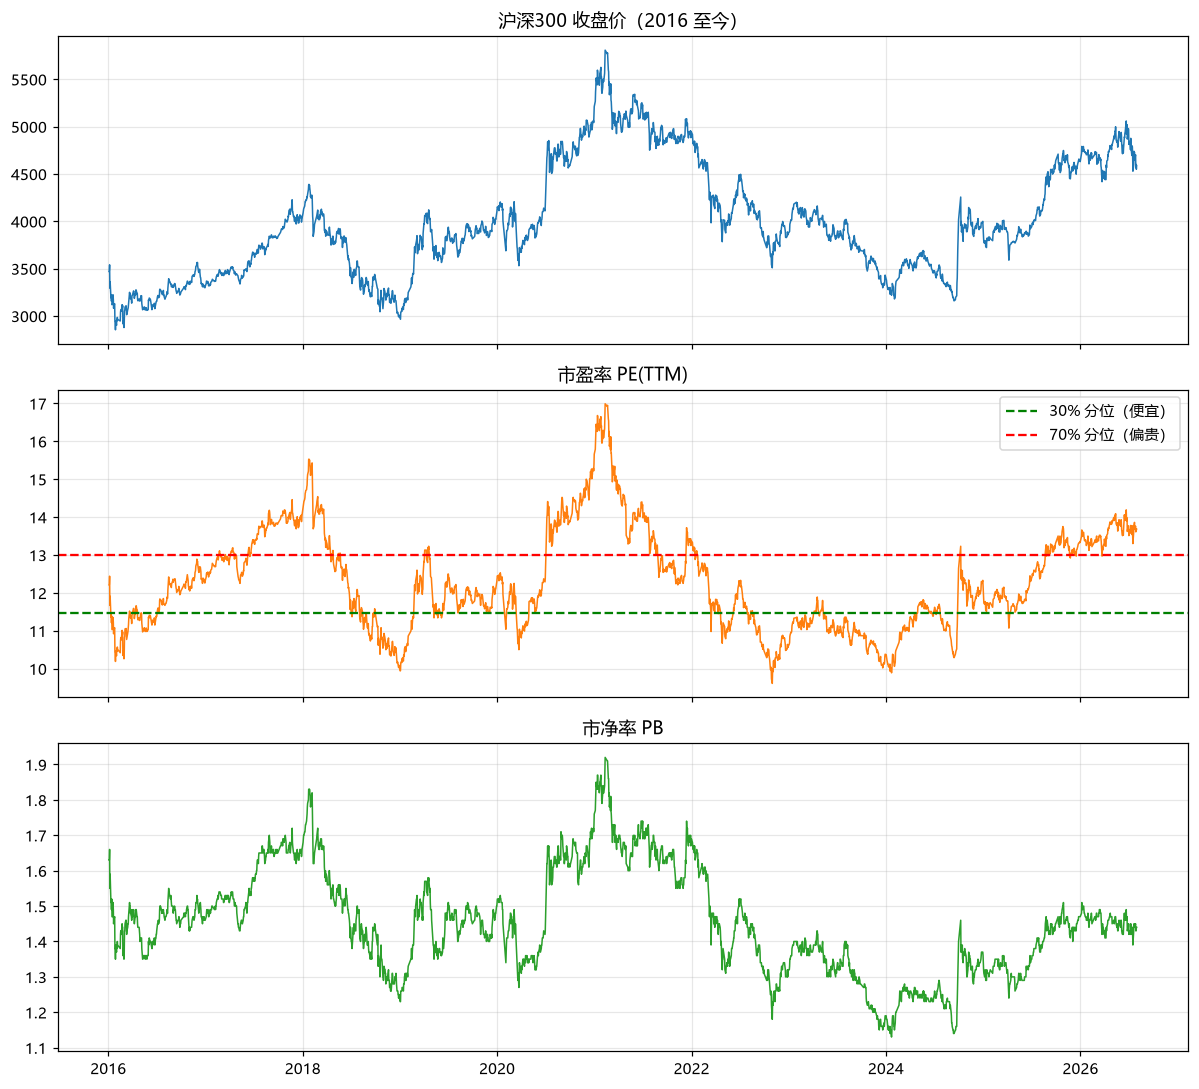

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].plot(px["date"], px["close"], lw=1)
axes[0].set_title("沪深300 收盘价（2016 至今）")
axes[0].grid(alpha=0.3)

axes[1].plot(px["date"], px["pe_ttm"], lw=1, color="tab:orange")
axes[1].axhline(px["pe_ttm"].quantile(0.30), color="g", ls="--", label="30% 分位（便宜）")
axes[1].axhline(px["pe_ttm"].quantile(0.70), color="r", ls="--", label="70% 分位（偏贵）")
axes[1].set_title("市盈率 PE(TTM)")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(px["date"], px["pb"], lw=1, color="tab:green")
axes[2].set_title("市净率 PB")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 第三步：把"买多少"变成一条可执行的规则

普通定投是每月固定金额；量化做法是**根据估值分位动态调整金额**：

| 估值分位 | 含义 | 当月投入倍数 |
|---|---|---|
| < 30% | 便宜 | 1.5 倍 |
| 30% - 70% | 中性 | 1.0 倍 |
| > 70% | 偏贵 | 0.5 倍 |

关键点：分位用**截至当天**的滚动历史计算，回测时不偷看未来数据。

In [6]:
# 用"截至当天"的历史计算分位（expanding 窗口，避免未来函数）
px["pe_pctile"] = px["pe_ttm"].expanding().apply(
    lambda a: float((a <= a[-1]).mean() * 100), raw=True
)

def multiplier(pctile):
    if pctile < 30:
        return 1.5
    if pctile > 70:
        return 0.5
    return 1.0

px["mult"] = px["pe_pctile"].map(multiplier)
px[["date", "close", "pe_ttm", "pe_pctile", "mult"]].head(5)

,date,close,pe_ttm,pe_pctile,mult
0,2016-01-04,3469.07,12.21,100.0,0.5
1,2016-01-05,3478.78,12.22,100.0,0.5
2,2016-01-06,3539.81,12.44,100.0,0.5
3,2016-01-07,3294.38,11.67,25.0,1.5
4,2016-01-08,3361.56,11.91,40.0,1.0


## 5. 第四步：回测对比——固定定投 vs 估值定投

模拟从 2016 年起每月 10 日买入：固定策略每月 ¥1,000；估值策略按上面的规则乘以倍数。

In [7]:
BASE_AMOUNT = 1000.0  # 每月基准金额（元）
BUY_DAY = 10          # 每月 10 日买入

months = pd.date_range(px["date"].min(), px["date"].max(), freq="MS") + pd.offsets.Day(BUY_DAY - 1)

def run_dca(scale_func):
    """返回 (累计投入, 期末市值, 逐月记录)"""
    invested, shares, records = 0.0, 0.0, []
    for d in months:
        row = px[px["date"] <= d].tail(1)  # 取当天或之前最近的一个交易日
        if row.empty:
            continue
        r = row.iloc[0]
        amount = BASE_AMOUNT * scale_func(r["pe_pctile"])
        shares += amount / r["close"]
        invested += amount
        records.append({"date": d.date(), "amount": amount, "price": r["close"]})
    final_price = px["close"].iloc[-1]
    return invested, shares * final_price, pd.DataFrame(records)

inv_fixed, val_fixed, rec_fixed = run_dca(lambda p: 1.0)
inv_value, val_value, rec_value = run_dca(multiplier)

summary = pd.DataFrame({
    "策略": ["固定金额定投", "估值定投"],
    "累计投入(元)": [inv_fixed, inv_value],
    "期末市值(元)": [val_fixed, val_value],
    "盈亏(元)": [val_fixed - inv_fixed, val_value - inv_value],
    "收益率": [
        (val_fixed / inv_fixed - 1) * 100,
        (val_value / inv_value - 1) * 100,
    ],
})
summary["收益率"] = summary["收益率"].round(1).astype(str) + "%"
summary.round(2)

,策略,累计投入(元),期末市值(元),盈亏(元),收益率
0,固定金额定投,126000.0,147895.98,21895.98,17.4%
1,估值定投,122000.0,146593.37,24593.37,20.2%


估值定投平均每月投入：968 元（基准 1000 元）
便宜（1.5 倍）的月份数：38
偏贵（0.5 倍）的月份数：46


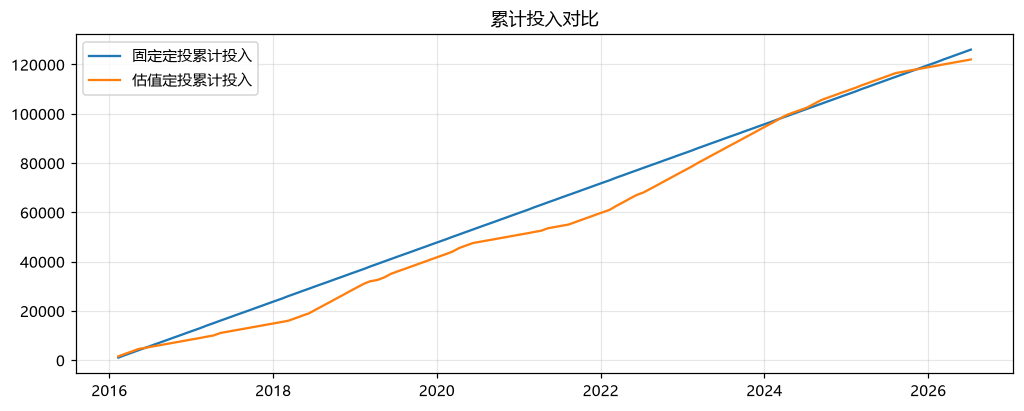

In [8]:
rec_value["mult"] = rec_value["amount"] / BASE_AMOUNT
print(f"估值定投平均每月投入：{rec_value['amount'].mean():.0f} 元（基准 {BASE_AMOUNT:.0f} 元）")
print(f"便宜（1.5 倍）的月份数：{(rec_value['mult'] == 1.5).sum()}")
print(f"偏贵（0.5 倍）的月份数：{(rec_value['mult'] == 0.5).sum()}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rec_fixed["date"], rec_fixed["amount"].cumsum(), label="固定定投累计投入")
ax.plot(rec_value["date"], rec_value["amount"].cumsum(), label="估值定投累计投入")
ax.set_title("累计投入对比")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. 当前信号：基于最新数据，现在该怎么买

In [9]:
last = px.iloc[-1]
signal = (
    "便宜区间，可多买" if last["pe_pctile"] < 30
    else "偏贵区间，可少买" if last["pe_pctile"] > 70
    else "中性区间，按原计划"
)
print(f"截至 {last['date'].date()}：")
print(f"  PE(TTM) = {last['pe_ttm']:.2f}，历史分位 = {last['pe_pctile']:.1f}%")
print(f"  按示例规则，当月定投倍数 = {multiplier(last['pe_pctile'])} 倍")
print(f"  结论：{signal}")

截至 2026-07-31：
  PE(TTM) = 13.68，历史分位 = 82.4%
  按示例规则，当月定投倍数 = 0.5 倍
  结论：偏贵区间，可少买


## 7. 拓展：看"趋势在不在"（动量）

估值回答"贵不贵"，动量回答"最近谁在涨"。把仓库里 11 个指数的最近 6 个月涨幅排个序，作为第二个决策输入。

In [10]:
slugs = ["sp500", "nasdaq_composite", "dow_jones", "nasdaq_100", "hang_seng",
         "csi_300", "shanghai_composite", "shenzhen_component", "nikkei_225",
         "ftse_100", "dax"]

rows = []
for slug in slugs:
    d = load_yearly_csv(ROOT / "02_Market/data/indices", slug)
    if len(d) < 130:
        continue
    ret_6m = d["close"].iloc[-1] / d["close"].iloc[-126] - 1
    rows.append({"指数": d["name"].iloc[-1], "最新日期": d["date"].iloc[-1].date(),
                 "最近6个月涨幅": ret_6m * 100})

momentum = pd.DataFrame(rows).sort_values("最近6个月涨幅", ascending=False)
momentum["最近6个月涨幅"] = momentum["最近6个月涨幅"].round(1).astype(str) + "%"
momentum.reset_index(drop=True)

,指数,最新日期,最近6个月涨幅
0,Nikkei 225,2026-07-31,20.7%
1,NASDAQ-100,2026-07-30,8.6%
2,S&P 500,2026-07-30,6.7%
3,Dow Jones Industrial Average,2026-07-30,6.4%
4,NASDAQ Composite,2026-07-30,6.1%
5,FTSE 100,2026-07-31,5.9%
6,DAX,2026-07-31,4.1%
7,Hang Seng Index,2026-07-31,-3.2%
8,CSI 300,2026-07-31,-3.6%
9,Shenzhen Component,2026-07-31,-5.2%


## 8. 总结与注意事项

这个 notebook 演示了量化买入分析的完整流程：**读数据 → 看估值 → 看风险 → 定规则 → 回测 → 看当前信号**。

几点必须记住：

1. **成本没算**：回测没有扣除手续费、滑点和基金申赎费，真实收益会低一些。
2. **用指数代替了基金**：你实际买的是基金，净值与指数有跟踪误差。
3. **参数是随便定的**：30%/70% 分位、1.5/0.5 倍数都是示例，调参要防过拟合，别反复"优化"同一段历史。
4. **过去不代表未来**：2016 年至今的结果只是历史，不是承诺。

下一步建议（按顺序）：

- 把你实际持有的三只基金（460300、021457、164705）的真实净值接进来，重跑一遍估值定投。
- 加入动量过滤：估值便宜 + 趋势不坏时再买。
- 模拟跑 2-3 个月，再考虑用小资金实盘。